# Tiny Shakespeare Dataset - RNN

### [Tiny Shakespeare Dataset](https://github.com/karpathy/char-rnn)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Andrej Karpathy, https://github.com/karpathy/char-rnn

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install numpy matplotlib

## Import Libraries

In [2]:
import urllib.request
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline

## Seed

In [3]:
SEED = 42
SEED

42

In [4]:
torch.manual_seed(SEED)

## Parameters

In [5]:
SEQ_LEN = 64
SEQ_LEN

64

In [6]:
EMBED_DIM = 64
EMBED_DIM

64

In [7]:
HIDDEN_DIM = 128
HIDDEN_DIM

128

## Hyperparameters

In [8]:
LEARNING_RATE = 0.002
LEARNING_RATE

0.002

In [9]:
EPOCHS = 10
EPOCHS

10

In [10]:
BATCH_SIZE = 128
BATCH_SIZE

128

## Device

In [11]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

## Download Dataset

Tiny Shakespeare is a real text corpus of about one million characters. We download it once and train a character-level model to predict the next character.

In [12]:
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
urllib.request.urlretrieve(URL, 'tinyshakespeare.txt')
with open('tinyshakespeare.txt', encoding='utf-8') as handle:
    text = handle.read()
print('length:', len(text))
print(text[:200])

length: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## Build Vocabulary

### Functions

In [13]:
def build_vocab(text):
    """
    Build character to index and index to character maps.

    Parameters:
        text (str): The training text.

    Returns:
        tuple: Character list, string to index, index to string.
    """
    chars = sorted(set(text))
    stoi = {ch: i for i, ch in enumerate(chars)}
    itos = {i: ch for i, ch in enumerate(chars)}
    return chars, stoi, itos


def encode(text, stoi):
    """
    Encode text as a tensor of indices.

    Parameters:
        text (str): The text to encode.
        stoi (dict): Character to index map.

    Returns:
        torch.Tensor: Encoded indices.
    """
    return torch.tensor([stoi[ch] for ch in text], dtype=torch.long)


def decode(indices, itos):
    """
    Decode indices back to text.

    Parameters:
        indices (list): Index values.
        itos (dict): Index to character map.

    Returns:
        str: The decoded text.
    """
    return ''.join(itos[i] for i in indices)

### Run

In [14]:
CHARS, STOI, ITOS = build_vocab(text)
VOCAB_SIZE = len(CHARS)
data = encode(text, STOI)
print('vocab size:', VOCAB_SIZE)
print('data shape:', data.shape)

vocab size: 65
data shape: torch.Size([1115394])


## Create Dataset

In [15]:
class CharDataset(torch.utils.data.Dataset):
    """
    A dataset of fixed-length character windows and next-character targets.
    """

    def __init__(self, data, seq_len):
        """
        Store the encoded text and window length.

        Parameters:
            data (torch.Tensor): Encoded text.
            seq_len (int): Length of each input window.

        Returns:
            None
        """
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        """
        Return the number of windows.

        Parameters:
            None

        Returns:
            int: Number of windows.
        """
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        """
        Return one input window and its shifted target.

        Parameters:
            idx (int): Window index.

        Returns:
            tuple: Input and target tensors.
        """
        x = self.data[idx:idx + self.seq_len]
        y = self.data[idx + 1:idx + self.seq_len + 1]
        return x, y

## Create DataLoader

In [16]:
split = int(0.9 * len(data))
train_data = CharDataset(data[:split], SEQ_LEN)
val_data = CharDataset(data[split:], SEQ_LEN)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
len(train_loader), len(val_loader)

(7843, 871)

## Create Model

In [17]:
class RNNModel(nn.Module):
    """
    A character-level recurrent network with an LSTM.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim):
        """
        Initialize the embedding, LSTM, and output layer.

        Parameters:
            vocab_size (int): Number of characters.
            embed_dim (int): Embedding size.
            hidden_dim (int): LSTM hidden size.

        Returns:
            None
        """
        super(RNNModel, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        Run the forward pass over a batch of windows.

        Parameters:
            x (torch.Tensor): Input index batch.
            hidden (tuple): Optional LSTM hidden state.

        Returns:
            tuple: Logits and the new hidden state.
        """
        x = self.embed(x)
        out, hidden = self.lstm(x, hidden)
        return self.fc(out), hidden

## Instantiate Model

In [18]:
torch.manual_seed(SEED)
model = RNNModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
model

RNNModel(
  (embed): Embedding(65, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=65, bias=True)
)

## Create Loss Function & Optimizer

In [19]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Train Model

### Functions

In [20]:
def train_epoch(model, loader, loss_fn, optimizer):
    """
    Train the model for a single epoch.

    Parameters:
        model (nn.Module): The model to train.
        loader (DataLoader): Training data loader.
        loss_fn (nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Parameter update rule.

    Returns:
        float: Mean training loss.
    """
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = model(x)
        loss = loss_fn(logits.transpose(1, 2), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


def evaluate(model, loader, loss_fn):
    """
    Evaluate the model over a loader.

    Parameters:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): Evaluation data loader.
        loss_fn (nn.Module): Loss function.

    Returns:
        float: Mean loss.
    """
    model.eval()
    total = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits, _ = model(x)
            total += loss_fn(logits.transpose(1, 2), y).item() * len(y)
    return total / len(loader.dataset)

### Training Loop

In [21]:
history = []
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    val_loss = evaluate(model, val_loader, loss_fn)
    history.append(val_loss)
    print(f"Epoch {epoch + 1:2d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

Epoch  1 | train loss 1.4800 | val loss 1.6200


Epoch  2 | train loss 1.3361 | val loss 1.6320


Epoch  3 | train loss 1.3117 | val loss 1.6469


Epoch  4 | train loss 1.2994 | val loss 1.6530


Epoch  5 | train loss 1.2918 | val loss 1.6691


Epoch  6 | train loss 1.2865 | val loss 1.6595


Epoch  7 | train loss 1.2825 | val loss 1.6639


Epoch  8 | train loss 1.2796 | val loss 1.6677


Epoch  9 | train loss 1.2773 | val loss 1.6769


Epoch 10 | train loss 1.2754 | val loss 1.6795


### Visualize Training

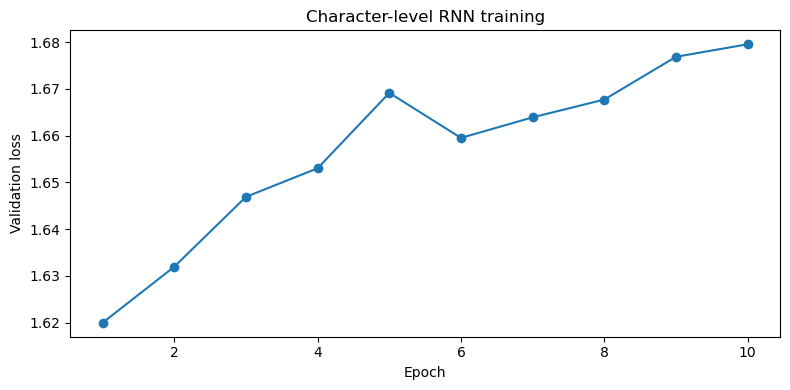

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.title('Character-level RNN training')
plt.tight_layout()
plt.show()

## Generate Text

### Function

In [23]:
def generate(model, start, length, temperature=0.8):
    """
    Generate text from a trained model.

    Parameters:
        model (nn.Module): Trained model.
        start (str): Seed text.
        length (int): Number of characters to generate.
        temperature (float): Sampling temperature.

    Returns:
        str: The generated text.
    """
    model.eval()
    indices = [STOI[ch] for ch in start]
    hidden = None
    with torch.no_grad():
        for _ in range(length):
            x = torch.tensor([indices[-1]]).unsqueeze(0).to(DEVICE)
            logits, hidden = model(x, hidden)
            probs = torch.softmax(logits[0, -1] / temperature, dim=0)
            next_index = torch.multinomial(probs, 1).item()
            indices.append(next_index)
    return decode(indices, ITOS)

### Run

In [24]:
print(generate(model, 'ROMEO: ', 300))

ROMEO: me your kingdom bad!

RIVERS:
Cloud hoteous unpriss.

VOLUMNIA:
I must have I am benefit no more
Than man of shepherd's son's reasons,
So far that will not say my soul is the ease.
I was less in that which the gods my kingdom merry.

DUKE VINCENTIO:
Your grace is hence, sir.

MERCUTIO:
Then so stand


## Save Model

In [25]:
torch.save(model.state_dict(), 'rnn_shakespeare.pt')
print('saved rnn_shakespeare.pt')

saved rnn_shakespeare.pt


## Load Model

In [26]:
loaded_model = RNNModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
loaded_model.load_state_dict(torch.load('rnn_shakespeare.pt', map_location=DEVICE))
loaded_model.eval()
print('loaded rnn_shakespeare.pt')

loaded rnn_shakespeare.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_55485/1614061309.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('rnn_

## Inference

In [27]:
print(generate(loaded_model, 'JULIET: ', 200))

JULIET: soul small again.

MERCUTIO:
Why, marry, what the thumbly Camillo, now the next enduation,
My better died this paint; for I hope he doomser mock'd their!

DUKE VINCENTIO:
Though not the just and membr
